# Precios Promedio de Gas Natural Comprimido Vehicular (GNCV) en diferentes estaciones de servicio de Colombia

# Contextualización de la Base de Datos

## Descripción General
La base de datos contiene información sobre los precios promedio de Gas Natural Comprimido Vehicular (GNCV) en diferentes estaciones de servicio de Colombia. Los datos incluyen detalles sobre la ubicación geográfica y temporal del precio reportado, permitiendo el análisis de la variabilidad de precios en el tiempo y el espacio.

## Objetivo de la Base de Datos
El propósito de esta base de datos es proporcionar información estructurada que permita realizar análisis sobre la distribución de precios del GNCV en Colombia, identificar patrones de variación geográfica y temporal, y facilitar la toma de decisiones en políticas energéticas y económicas.

## Descripción de las Variables

### Variables Temporales:
- **FECHA_PRECIO**: Fecha del precio reportado (YYYY-MM-DD).
- **ANIO_PRECIO**: Año del precio reportado.
- **MES_PRECIO**: Mes del precio reportado.
- **DIA_PRECIO**: Día del precio reportado.

### Variables Geográficas:
- **DEPARTAMENTO_EDS**: Departamento donde se encuentra la estación de servicio.
- **MUNICIPIO_EDS**: Municipio donde se encuentra la estación de servicio.
- **CODIGO_MUNICIPIO_DANE**: Código DANE del municipio.
- **LATITUD_MUNICIPIO**: Coordenada de latitud del municipio.
- **LONGITUD_MUNICIPIO**: Coordenada de longitud del municipio.

### Variables de la Estación de Servicio:
- **NOMBRE_COMERCIAL_EDS**: Nombre comercial de la estación de servicio.
- **TIPO_COMBUSTIBLE**: Tipo de combustible (en este caso, "GNCV").

### Variable de Precio:
- **PRECIO_PROMEDIO_PUBLICADO**: Precio promedio del GNCV en la estación de servicio (en pesos colombianos).




In [1]:
# Librerias 

import pandas as pd
import geopandas as gpd
import janitor as jan
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import warnings
from matplotlib.colors import Normalize

In [2]:
# Ruta en Mac (ajústala si es necesario)
csv_path = "/Users/elianafuentes/Documents/DATAVIZMAPAS/Consulta_Precios_Promedio_de_Gas_Natural_Comprimido_Vehicular__AUTOMATIZADO__20250314.csv"

# Cargar el archivo CSV
df = pd.read_csv(csv_path, encoding="latin1") 

FileNotFoundError: [Errno 2] No such file or directory: '/Users/elianafuentes/Documents/DATAVIZMAPAS/Consulta_Precios_Promedio_de_Gas_Natural_Comprimido_Vehicular__AUTOMATIZADO__20250314.csv'

In [4]:
# Ver las primeras filas
df.head()


,FECHA_PRECIO,ANIO_PRECIO,MES_PRECIO,DIA_PRECIO,DEPARTAMENTO_EDS,MUNICIPIO_EDS,NOMBRE_COMERCIAL_EDS,PRECIO_PROMEDIO_PUBLICADO,TIPO_COMBUSTIBLE,CODIGO_MUNICIPIO_DANE,LATITUD_MUNICIPIO,LONGITUD_MUNICIPIO
0,2024-09-01,2024,9,1,SANTANDER,BUCARAMANGA,CAMOVA,2299,GNCV,68001,7.155834,-73.111572
1,2024-07-01,2024,7,1,SANTANDER,BUCARAMANGA,CAMOVA,2249,GNCV,68001,7.155834,-73.111572
2,2024-10-01,2024,10,1,CUNDINAMARCA,CHIA,CHIA EDS - GNV,2787,GNCV,25175,4.857824,-74.038094
3,2024-10-01,2024,10,1,CALDAS,MANIZALES,ESTACIÃN DE SERVICIO CALDAS,3324,GNCV,17001,5.083433,-75.507278
4,2024-10-01,2024,10,1,BOGOTA D.C.,"BOGOTA, D.C.",ESTACION DE SERVICIO COMBUSCOL EL DORADO,2718,GNCV,11001,4.652954,-74.083565


# Tipos de Variables 

In [5]:
# Definir las variables y su tipo según tu dataset
dict_variables = { 
    "Macro Variable": [
        "FECHA_PRECIO", "MES", "DEPARTAMENTO_EDS", "MUNICIPIO_EDS", 
        "NOMBRE_COMERCIAL_EDS", "TIPO_COMBUSTIBLE", "PRECIO_PROMEDIO_PUBLICADO"
    ], 
    "Tipo": [
        "Cuantitativa Discreta", "Cualitativa Ordinal", "Cualitativa Nominal", 
        "Cualitativa Nominal", "Cualitativa Nominal", "Cualitativa Nominal", 
        "Cuantitativa Continua"
    ]   
}

# Convertir a DataFrame
df_variables = pd.DataFrame(dict_variables)

# Mostrar el DataFrame
df_variables

,Macro Variable,Tipo
0,FECHA_PRECIO,Cuantitativa Discreta
1,MES,Cualitativa Ordinal
2,DEPARTAMENTO_EDS,Cualitativa Nominal
3,MUNICIPIO_EDS,Cualitativa Nominal
4,NOMBRE_COMERCIAL_EDS,Cualitativa Nominal
5,TIPO_COMBUSTIBLE,Cualitativa Nominal
6,PRECIO_PROMEDIO_PUBLICADO,Cuantitativa Continua


### **Variables Cuantitativas**
- **FECHA_PRECIO (Discreta):** Representa el día en que se registró el precio del GNCV.
- **PRECIO_PROMEDIO_PUBLICADO (Continua):** Indica el precio promedio del GNCV en las estaciones de servicio. 

### **Variables Cualitativas**
- **MES (Ordinal):** Indica el mes del año.
- **DEPARTAMENTO_EDS y MUNICIPIO_EDS (Nominales):** Ubican geográficamente las estaciones de servicio.
- **NOMBRE_COMERCIAL_EDS (Nominal):** Identifica la marca o nombre de la estación.
- **TIPO_COMBUSTIBLE (Nominal):** Indica el tipo de combustible vendido en la estación.


In [6]:
# Información sobre las columnas y tipos de datos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9855 entries, 0 to 9854
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   FECHA_PRECIO               9855 non-null   object 
 1   ANIO_PRECIO                9855 non-null   int64  
 2   MES_PRECIO                 9855 non-null   int64  
 3   DIA_PRECIO                 9855 non-null   int64  
 4   DEPARTAMENTO_EDS           9855 non-null   object 
 5   MUNICIPIO_EDS              9855 non-null   object 
 6   NOMBRE_COMERCIAL_EDS       9855 non-null   object 
 7   PRECIO_PROMEDIO_PUBLICADO  9855 non-null   int64  
 8   TIPO_COMBUSTIBLE           9855 non-null   object 
 9   CODIGO_MUNICIPIO_DANE      9855 non-null   int64  
 10  LATITUD_MUNICIPIO          9855 non-null   float64
 11  LONGITUD_MUNICIPIO         9855 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 924.0+ KB


In [7]:
# Seleccionar solo las variables importantes
df_numeric = df[['ANIO_PRECIO', 'PRECIO_PROMEDIO_PUBLICADO', 'LATITUD_MUNICIPIO', 'LONGITUD_MUNICIPIO']]

In [8]:
# Resumen estadístico de las variables numéricas
df_numeric.describe()


,ANIO_PRECIO,PRECIO_PROMEDIO_PUBLICADO,LATITUD_MUNICIPIO,LONGITUD_MUNICIPIO
count,9855.000000,9855.000000,9855.000000,9855.000000
mean,2022.702790,2169.798478,5.825072,-75.007978
std,1.170838,502.294147,2.517967,1.054845
min,2021.000000,0.000000,1.749139,-77.118729
25%,2022.000000,1800.000000,4.499501,-75.795792
50%,2023.000000,2089.000000,4.652954,-74.827713
75%,2024.000000,2438.000000,6.257590,-74.083565
max,2025.000000,19719.000000,11.121895,-70.869469


# Valores Faltantes

In [9]:
# Análisis de valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())



Valores faltantes por columna:
FECHA_PRECIO                 0
ANIO_PRECIO                  0
MES_PRECIO                   0
DIA_PRECIO                   0
DEPARTAMENTO_EDS             0
MUNICIPIO_EDS                0
NOMBRE_COMERCIAL_EDS         0
PRECIO_PROMEDIO_PUBLICADO    0
TIPO_COMBUSTIBLE             0
CODIGO_MUNICIPIO_DANE        0
LATITUD_MUNICIPIO            0
LONGITUD_MUNICIPIO           0
dtype: int64


## Análisis 

-  No hay valores faltantes en ninguna de las variables, lo que indica que la base de datos está completa y lista para su análisis sin necesidad de imputaciones o limpiezas adicionales.

In [10]:
df.shape

(9855, 12)

In [11]:
# Número de departamentos, municipios y estaciones únicas
unique_values = {
    "Departamentos únicos": df["DEPARTAMENTO_EDS"].nunique(),
    "Municipios únicos": df["MUNICIPIO_EDS"].nunique(),
    "Estaciones de servicio únicas": df["NOMBRE_COMERCIAL_EDS"].nunique(),
    "Tipos de combustible": df["TIPO_COMBUSTIBLE"].unique()
}

unique_values

{'Departamentos únicos': 21,
 'Municipios únicos': 85,
 'Estaciones de servicio únicas': 471,
 'Tipos de combustible': array(['GNCV'], dtype=object)}

## Interpretación de los Datos

- **Cobertura geográfica:**  
  La base de datos abarca **21 departamentos** y **85 municipios** de Colombia, lo que permite realizar análisis espaciales y regionales sobre la distribución y variación de precios del GNCV.  

- **Número de estaciones de servicio:**  
  Se cuenta con información de **471 estaciones de servicio**, lo que indica una cobertura amplia y suficiente para realizar estudios sobre el comportamiento de precios en distintas regiones.  

- **Variedad de combustibles:**  
  En este conjunto de datos, **solo se encuentra el tipo de combustible "GNCV"**, lo que confirma que el análisis se centrará exclusivamente en este tipo de energía vehicular.  


# Distribución de precios promedio de GNCV

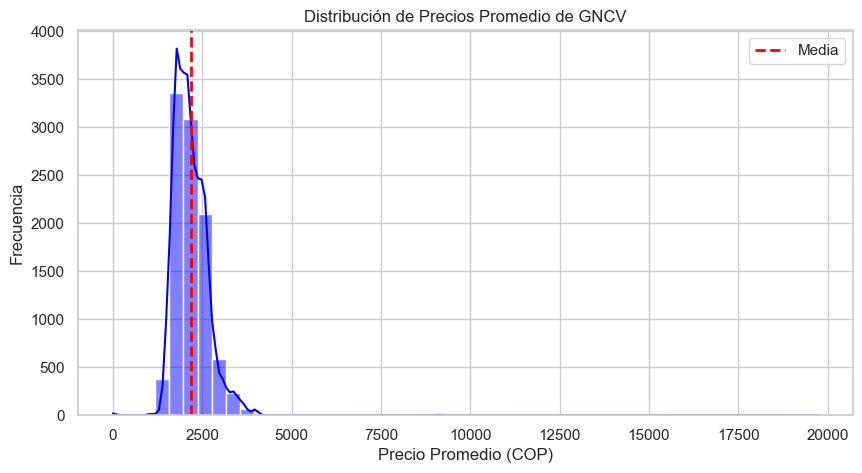

In [12]:
# Configuración de estilo
sns.set(style="whitegrid")

# Histograma de precios
plt.figure(figsize=(10, 5))
sns.histplot(df["PRECIO_PROMEDIO_PUBLICADO"], bins=50, kde=True, color="blue")
plt.axvline(df["PRECIO_PROMEDIO_PUBLICADO"].mean(), color='red', linestyle='dashed', linewidth=2, label="Media")
plt.title("Distribución de Precios Promedio de GNCV")
plt.xlabel("Precio Promedio (COP)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

## Interpretación de la Distribución de precios promedio de GNCV
- **Forma de la distribución:**  
  La distribución tiene una fuerte asimetría positiva (sesgo a la derecha), lo que indica que la mayoría de los precios promedio están concentrados en un rango bajo, pero existen valores atípicos elevados que extienden la cola de la distribución.  

- **Rango de precios:**  
  La mayoría de los precios se encuentran entre **2,000 y 3,000 COP**, con una alta frecuencia en este intervalo.

- **Posición de la media:**  
  La media, representada por la línea roja punteada, está ligeramente desplazada hacia la derecha, lo que confirma el sesgo positivo. Esto significa que algunos precios elevados están influyendo en la media, elevándola por encima del valor más frecuente.  


# Distribución de Precios por Departamento

/var/folders/70/380whh_x6t31tncscvq5h0qr0000gn/T/ipykernel_992/3224358010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="PRECIO_PROMEDIO_PUBLICADO", y="DEPARTAMENTO_EDS", data=df, palette="coolwarm")


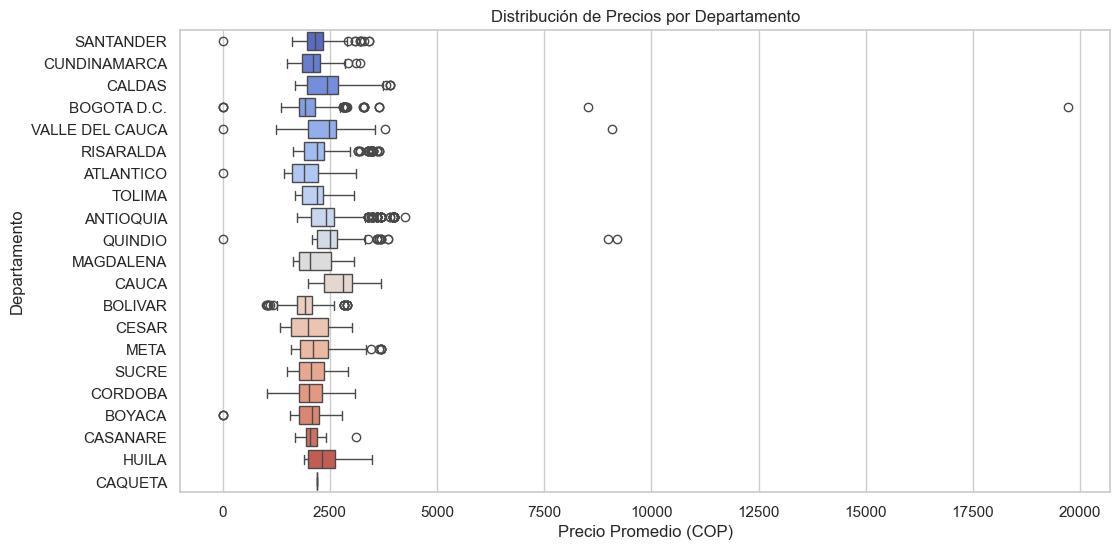

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="PRECIO_PROMEDIO_PUBLICADO", y="DEPARTAMENTO_EDS", data=df, palette="coolwarm")
plt.title("Distribución de Precios por Departamento")
plt.xlabel("Precio Promedio (COP)")
plt.ylabel("Departamento")
plt.show()
warnings.simplefilter(action="ignore", category=FutureWarning)

# Análisis de la Distribución de Precios por Departamento

La gráfica presenta la distribución de precios promedio en diferentes departamentos de Colombia. A continuación, se realiza un análisis de la información proporcionada:

## Interpretación de la Gráfica

1. **Departamentos Representados**: La gráfica incluye una lista de departamentos colombianos, como Santander, Cundinamarca, Caldas, Bogotá D.C., Valle del Cauca, entre otros.

2. **Rango de Precios**: Los precios promedio están distribuidos en un rango que va desde 2,500 COP hasta 20,000 COP, con incrementos de 2,500 COP.


## Análisis

- **Variabilidad Regional**: La gráfica sugiere una variabilidad significativa en los precios promedio entre los diferentes departamentos, lo que podría reflejar diferencias en el desarrollo económico, la oferta y la demanda, y otros factores regionales.

- **Implicaciones**: Esta distribución de precios puede ser útil para identificar áreas con mayores oportunidades de inversión, regiones con necesidades específicas de políticas económicas, o para el análisis de mercados específicos.



# Evolucion del Precio por Departamento

In [14]:
#  Tendencias temporales
# Convertir FECHA_PRECIO a tipo datetime
df['FECHA_PRECIO'] = pd.to_datetime(df['FECHA_PRECIO'])

In [15]:
# Agrupar por fecha y calcular el precio promedio
df_temporal = df.groupby('FECHA_PRECIO')['PRECIO_PROMEDIO_PUBLICADO'].mean().reset_index()

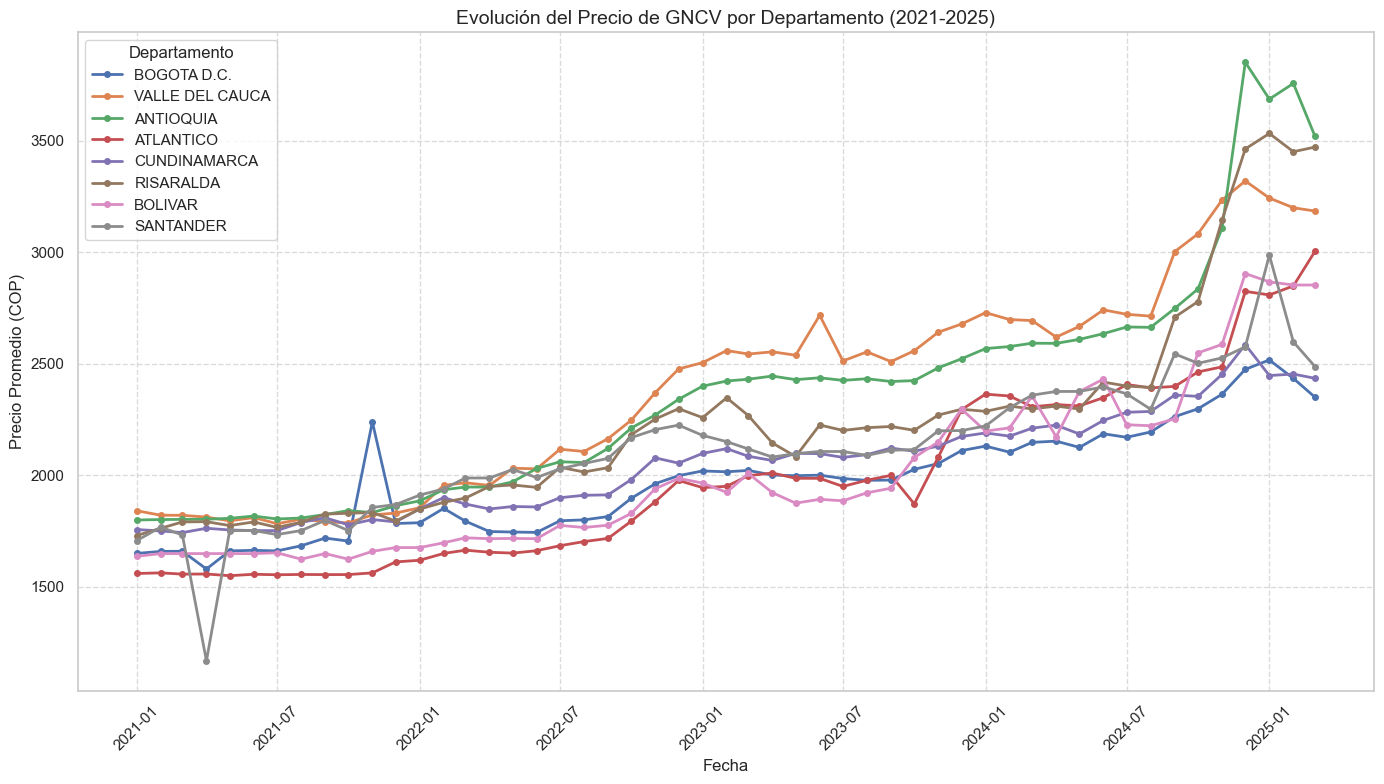

In [16]:
# Crear un gráfico de evolución temporal de precios
# Definir las columnas necesarias
departamento_col = 'DEPARTAMENTO_EDS'
fecha_col = 'FECHA_PRECIO'
precio_col = 'PRECIO_PROMEDIO_PUBLICADO'

# Seleccionar los 8 departamentos con más datos para el análisis temporal
dptos_con_mas_datos = df[departamento_col].value_counts().nlargest(8).index.tolist()

# Filtrar los datos para esos departamentos
df_seleccionados = df[df[departamento_col].isin(dptos_con_mas_datos)]

# Agrupar por fecha y departamento para obtener precio promedio mensual
df_tiempo = df_seleccionados.groupby([pd.Grouper(key=fecha_col, freq='MS'), departamento_col])[precio_col].mean().reset_index()

# Crear gráfico de líneas
plt.figure(figsize=(14, 8))

# Para cada departamento, graficar la evolución de precios
for dpto in dptos_con_mas_datos:
    df_dpto = df_tiempo[df_tiempo[departamento_col] == dpto]
    plt.plot(df_dpto[fecha_col], df_dpto[precio_col], marker='o', markersize=4, linewidth=2, label=dpto)

plt.title('Evolución del Precio de GNCV por Departamento (2021-2025)', fontsize=14)
plt.ylabel('Precio Promedio (COP)', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Departamento', loc='best')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('evolucion_precios_gncv_colombia.png', dpi=300, bbox_inches='tight')
plt.show()


## Análisis de la grafica Evolucion del Precio por Departamento

- **Tendencia Temporal**: 

  - **2021Q1 - 2025Q1**: La gráfica muestra la evolución trimestral del precio, lo que permite identificar tendencias a corto y largo plazo.

- **Variabilidad por Departamento**: 
  - **Diferencias Regionales**: Los precios pueden variar significativamente entre departamentos debido a factores como la infraestructura de distribución, la demanda local y los costos operativos.
  - **Departamentos con Mayor Variación**: Algunos departamentos pueden mostrar una mayor fluctuación en los precios, lo que podría estar relacionado con eventos específicos o cambios en la oferta y demanda.

- **Factores Influentes**: 
  - **Económicos**: Cambios en la economía global o nacional, como fluctuaciones en los precios del petróleo, pueden afectar los precios del GNCV.
  - **Políticos**: Políticas gubernamentales, subsidios o impuestos pueden influir en la evolución de los precios.
  
- **Tendencia General**: 
   - **Aumento Gradual**: Si los precios muestran un incremento constante a lo largo del tiempo, esto podría indicar un aumento en los costos de producción, distribución o una mayor demanda de GNCV.

- **Diferencias por Departamento**:
   - **Departamentos con Mayor Aumento**: Algunos departamentos pueden mostrar un aumento más pronunciado en los precios, lo que podría estar relacionado con una mayor demanda, costos de distribución más altos o limitaciones en la infraestructura.
   - **Departamentos con Menor Aumento o Estabilidad**: Otros departamentos pueden experimentar aumentos menores o mantener precios estables, lo que podría indicar una mejor infraestructura, menor demanda o políticas locales que estabilizan los precios.

# Tendencia Temporal de Precios Promedio

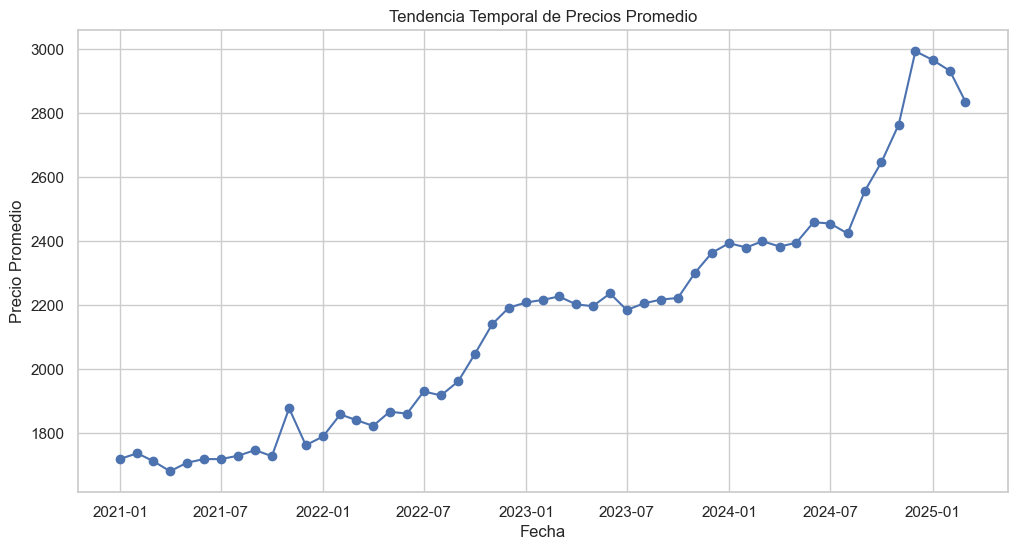

In [17]:
# Gráfico de tendencia temporal
plt.figure(figsize=(12, 6))
plt.plot(df_temporal['FECHA_PRECIO'], df_temporal['PRECIO_PROMEDIO_PUBLICADO'], marker='o')
plt.title("Tendencia Temporal de Precios Promedio")
plt.xlabel("Fecha")
plt.ylabel("Precio Promedio")
plt.grid(True)
plt.show()

## Analisis grafica Tendencia Temporal de Precios Promedio
### **1. Tendencia General**  
- Se observa una clara **tendencia alcista** en los precios a lo largo del período analizado.  
- Entre **2021 y mediados de 2022**, el precio se mantiene relativamente estable, con pequeñas fluctuaciones.  
- A partir de **mediados de 2022**, se inicia un **aumento sostenido** en los precios, que continúa hasta alcanzar su punto máximo en 2025.  

### **2. Etapas Clave**  
- **2021 - 2022:** Variabilidad moderada con ligeros picos, pero sin una tendencia definida.  
- **2022 - 2023:** Se observa un crecimiento acelerado en los precios, con un incremento constante.  
- **2023 - 2024:** Periodo de relativa estabilidad con fluctuaciones menores.  
- **2024 - 2025:** Se presenta un aumento significativo en los precios, alcanzando un pico alrededor de finales de 2024, seguido por un leve descenso.  


#  Tendencia Temporal de Precios Promedio por Año y Mes  

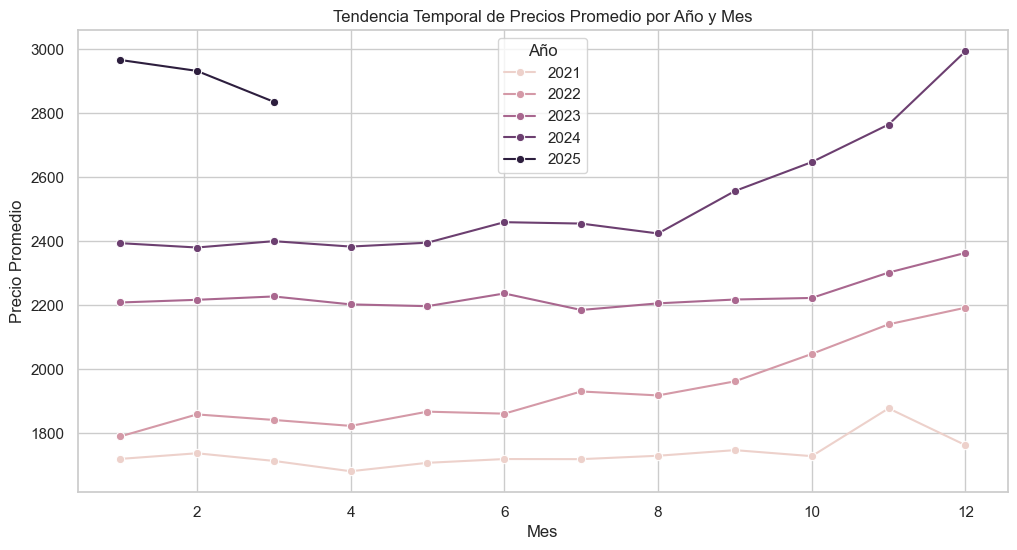

In [18]:
# Tendencias temporales (por año y mes)
df_temporal = df.groupby(['ANIO_PRECIO', 'MES_PRECIO'])['PRECIO_PROMEDIO_PUBLICADO'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_temporal, x='MES_PRECIO', y='PRECIO_PROMEDIO_PUBLICADO', hue='ANIO_PRECIO', marker='o')
plt.title("Tendencia Temporal de Precios Promedio por Año y Mes")
plt.xlabel("Mes")
plt.ylabel("Precio Promedio")
plt.legend(title="Año")
plt.grid(True)
plt.show()

## Análisis de la Tendencia Temporal de Precios Promedio por Año y Mes  
###  Descripción de la Gráfica  
Esta visualización muestra la evolución de los precios promedio a lo largo de los meses, desglosada por año (2021-2025). Cada línea representa un año y permite observar patrones estacionales y la evolución general de los precios.  

### Interpretación  
### **1. Tendencia General a lo Largo de los Años**  
- Hay un **aumento progresivo en los precios** con el paso de los años.  
- Los precios en 2021 son los más bajos, mientras que en 2025 alcanzan su nivel más alto.  

### **2. Comportamiento Mensual**  
- **2021 y 2022:** Los precios son relativamente bajos y estables, con ligeros aumentos hacia fin de año.  
- **2023 y 2024:** Se observa un incremento más pronunciado en la segunda mitad del año, especialmente en los últimos meses.  
- **2025:** Muestra los precios más elevados, con una ligera disminución en los primeros meses y luego una fuerte subida hacia diciembre.  


# Precios Promedio por Departamento

In [19]:
# Análisis por departamento
print("\nPrecios promedio por departamento:")
precio_por_departamento = df.groupby('DEPARTAMENTO_EDS')['PRECIO_PROMEDIO_PUBLICADO'].mean().sort_values(ascending=False)
print(precio_por_departamento)


Precios promedio por departamento:
DEPARTAMENTO_EDS
CAUCA              2744.000000
QUINDIO            2580.133333
CALDAS             2432.657778
ANTIOQUIA          2412.356203
VALLE DEL CAUCA    2393.043194
HUILA              2362.864407
RISARALDA          2244.392045
META               2227.552795
CAQUETA            2200.000000
SANTANDER          2174.259740
MAGDALENA          2154.355263
TOLIMA             2134.096386
SUCRE              2087.077922
CUNDINAMARCA       2073.772829
CORDOBA            2070.172973
CASANARE           2061.209677
BOYACA             2055.352941
CESAR              2048.613208
BOGOTA D.C.        1980.824542
ATLANTICO          1958.934077
BOLIVAR            1950.318471
Name: PRECIO_PROMEDIO_PUBLICADO, dtype: float64


# Interpretación de los Precios Promedio por Departamento

La tabla presenta los precios promedio publicados:

## Análisis General

1. **Rango de Precios**: Los precios promedio varían desde aproximadamente 1,950 COP hasta 2,744 COP. Esto indica una variabilidad significativa en los precios entre los diferentes departamentos.

2. **Departamentos con Precios Más Altos**:
   - **Cauca (2,744 COP)**: Este departamento tiene el precio promedio más alto, lo que podría deberse a factores como una mayor demanda, costos de distribución más elevados o una oferta limitada.
   - **Quindío (2,580 COP)** y **Caldas (2,433 COP)**: Estos departamentos también presentan precios relativamente altos, lo que podría estar relacionado con características económicas o geográficas específicas.

3. **Departamentos con Precios Más Bajos**:
   - **Bolívar (1,950 COP)** y **Atlántico (1,959 COP)**: Estos departamentos tienen los precios promedio más bajos, lo que podría indicar una mayor oferta, menores costos de distribución o una menor demanda.
   - **Bogotá D.C. (1,981 COP)**: A pesar de ser la capital, tiene uno de los precios más bajos, lo que podría deberse a una mayor competencia o una infraestructura más eficiente.

# Precio Promedio por Departamento 

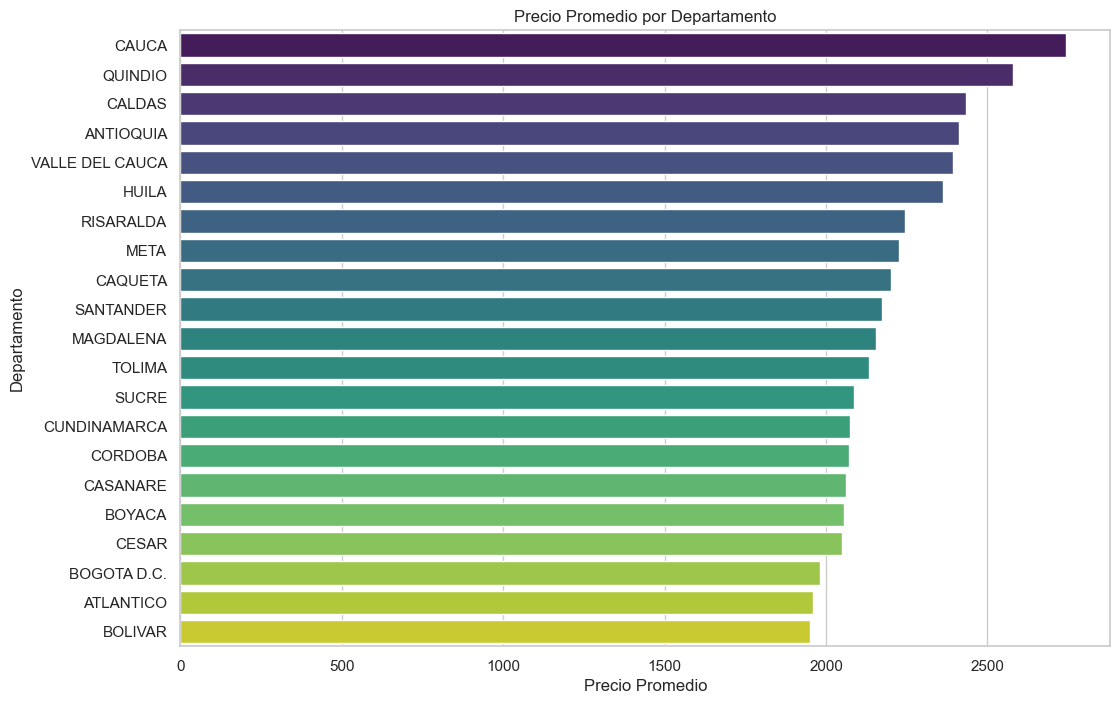

In [20]:
# Gráfico de barras para precios por departamento
plt.figure(figsize=(12, 8))
sns.barplot(x=precio_por_departamento.values, y=precio_por_departamento.index, palette="viridis")
plt.title("Precio Promedio por Departamento")
plt.xlabel("Precio Promedio")
plt.ylabel("Departamento")
plt.show()
warnings.simplefilter(action="ignore", category=FutureWarning)

# Análisis del Precio Promedio por Departamento 

##  Interpretación  
### **1. Departamentos con Precios Más Altos**  
- **Cauca, Quindío y Caldas** son los departamentos con el precio promedio más alto.  
- También destacan **Antioquia y Valle del Cauca**, lo que sugiere que estas regiones tienen una mayor demanda o costos de producción elevados.  

### **2. Departamentos con Precios Intermedios**  
- Huila, Risaralda, Meta y Caquetá tienen precios en un rango medio, lo que podría indicar mercados más estables o en crecimiento.  

### **3. Departamentos con Precios Más Bajos**  
- **Bolívar, Atlántico y Bogotá D.C.** están en la parte inferior del ranking, lo que sugiere que los precios en estas zonas son relativamente más accesibles.  
- Esto puede deberse a una mayor oferta, menores costos de producción o dinámicas del mercado local.  


# Top 10 Municipios con Precios Más Altos  

In [21]:
# Análisis por municipio (top 10 municipios con precios más altos)
print("\nTop 10 municipios con precios más altos:")
top_municipios = df.groupby('MUNICIPIO_EDS')['PRECIO_PROMEDIO_PUBLICADO'].mean().sort_values(ascending=False).head(10)
print(top_municipios)


Top 10 municipios con precios más altos:
MUNICIPIO_EDS
FLORIDA                   3315.000000
SANTANDER DE QUILICHAO    3023.941176
LA CEJA                   2813.117647
RIOFRIO                   2750.500000
PIEDECUESTA               2749.400000
TULUA                     2691.273585
ENVIGADO                  2685.000000
AGUACHICA                 2619.000000
ARMENIA                   2589.759398
POPAYAN                   2585.366667
Name: PRECIO_PROMEDIO_PUBLICADO, dtype: float64


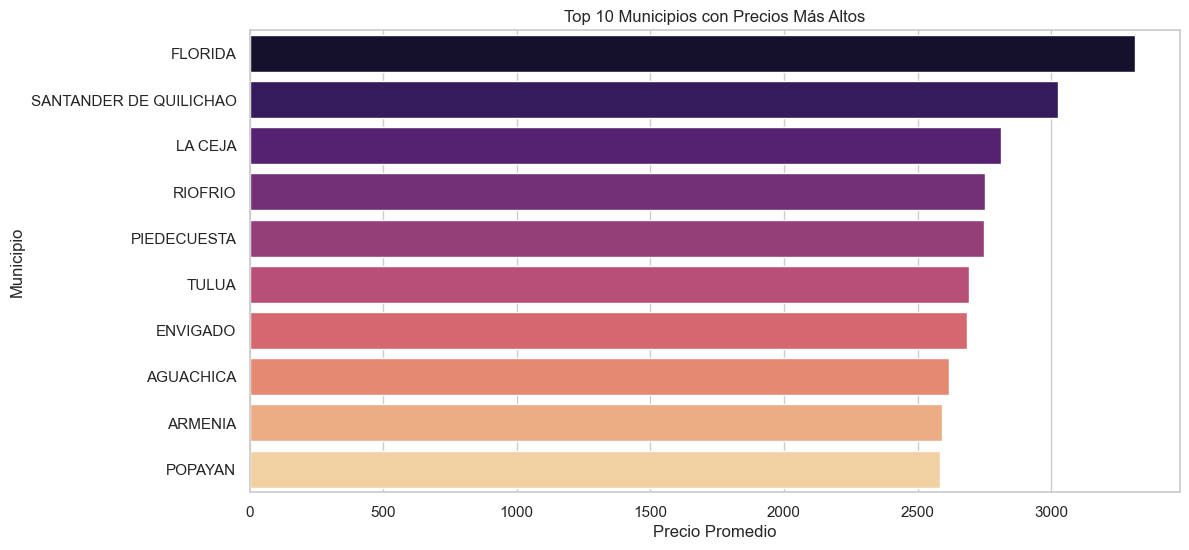

In [22]:
# Gráfico de barras para top 10 municipios
plt.figure(figsize=(12, 6))
sns.barplot(x=top_municipios.values, y=top_municipios.index, palette="magma")
plt.title("Top 10 Municipios con Precios Más Altos")
plt.xlabel("Precio Promedio")
plt.ylabel("Municipio")
plt.show()
warnings.simplefilter(action="ignore", category=FutureWarning)



## Descripción de la Gráfica  
Esta visualización muestra los **10 municipios con los precios promedio más altos**. Están ordenados de mayor a menor, siendo **Florida** el municipio con el precio más alto y **Popayán** el de menor precio dentro de este top.  

##  Interpretación  
### **1. Municipios con Precios Más Altos**  
- **Florida y Santander de Quilichao** lideran la lista con los precios más elevados.  
- Esto podría deberse a una alta demanda, costos de producción elevados o características geográficas y económicas específicas de la región.  

### **2. Municipios con Precios Intermedios en el Ranking**  
- **La Ceja, Riofrío y Piedecuesta** presentan precios similares, lo que sugiere una tendencia estable en estas zonas.  

### **3. Municipios en la Parte Baja del Ranking**  
- **Envigado, Aguachica, Armenia y Popayán** cierran la lista, aunque siguen estando entre los más caros del país.  
- A pesar de estar en los últimos lugares de este top, sus precios siguen siendo relativamente altos en comparación con otros municipios.  


#  Matriz de Correlación  

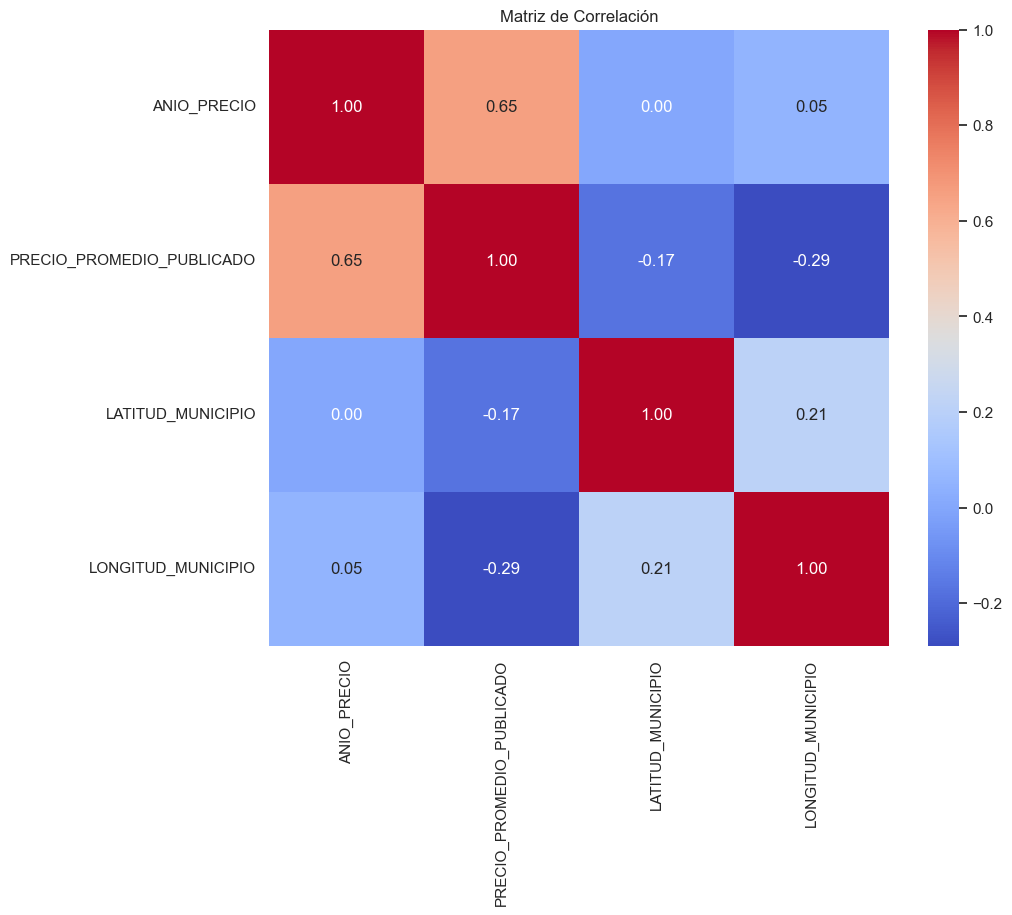

In [23]:
# Correlación entre variables numéricas


# Matriz de correlación
corr_matrix = df_numeric.corr()

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()


## Interpretación de las correlaciones  

### 1️ **Relación entre Año y Precio Promedio Publicado** (**0.65**)  
- Hay una correlación positiva moderada entre el **año** y el **precio promedio publicado**.  
- Esto sugiere que los precios han **aumentado con el tiempo**, aunque no es una relación perfecta.  

### **Relación entre Precio Promedio y Latitud/Longitud**  
- **Latitud vs. Precio Promedio (-0.17)** y **Longitud vs. Precio Promedio (-0.29)** muestran correlaciones negativas débiles.  
- Esto indica que la **ubicación geográfica tiene poca influencia directa** sobre el precio promedio.  
- Sin embargo, podría haber factores externos (como infraestructura o demanda) que expliquen mejor la variación de precios.  

### **Relación entre Latitud y Longitud (0.21)**  
- La latitud y longitud tienen una **correlación positiva baja**, lo que es esperable ya que ambas están relacionadas con la ubicación geográfica.  

##  Conclusión  
- El precio promedio ha tendido a subir con los años.  
- La ubicación (latitud/longitud) no parece ser un factor determinante en los precios, al menos de forma directa.  

# Georreferenciación del Precio Promedio del Gas Natural Comprimido Vehicular (GNCV) en Estaciones de Servicio de Colombia

In [24]:
# Cargar el shapefile de Colombia
shapefile_path ="/Users/elianafuentes/Documents/DATAVIZMAPAS/COLOMBIA/COLOMBIA.shp"
gdf_colombia = gpd.read_file(shapefile_path,encoding="latin1")

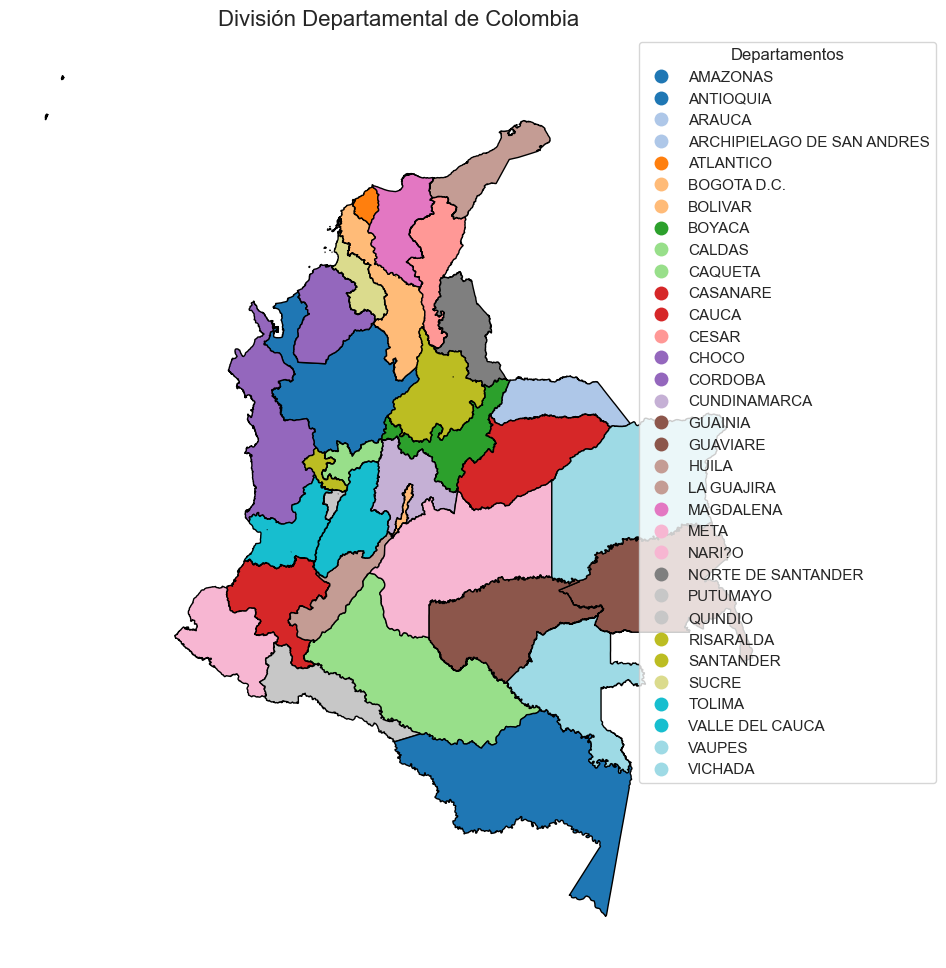

In [25]:
# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(15, 12))

# Graficar el mapa con colores por departamento
gdf_colombia.plot(ax=ax, column="DPTO_CNMBR", cmap="tab20", edgecolor="black", linewidth=1, legend=True)

# Agregar título
plt.title("División Departamental de Colombia", fontsize=16)

# Ajustar la leyenda para que no cubra el mapa
leg = ax.get_legend()
if leg:
    leg.set_bbox_to_anchor((1.2, 1))  # Mueve la leyenda fuera del mapa
    leg.set_title("Departamentos")  # Agrega título a la leyenda

# Quitar ejes
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Mostrar el mapa
plt.show()

In [26]:
# Definir las columnas correctas según la información proporcionada
departamento_col = 'DEPARTAMENTO_EDS'  # Columna de departamento en el CSV
precio_col = 'PRECIO_PROMEDIO_PUBLICADO'  # Columna de precio en el CSV
fecha_col = 'FECHA_PRECIO'  # Columna de fecha en el CSV
departamento_geo_col = 'DPTO_CNMBR'  # Columna de departamento en el shapefile



In [27]:
# Convertir la columna de fecha a formato datetime
df[fecha_col] = pd.to_datetime(df[fecha_col])

# Asegurarse de que los nombres de departamentos coincidan entre ambos conjuntos de datos
# Normalizar nombres (convertir a mayúsculas y eliminar acentos)
df[departamento_col] = df[departamento_col].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
gdf_colombia[departamento_geo_col] = gdf_colombia[departamento_geo_col].str.upper().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Obtener el último mes de datos disponibles
ultimo_mes = df[fecha_col].max()
df_ultimo_mes = df[df[fecha_col] == ultimo_mes]

In [28]:
# Calcular el precio promedio por departamento para el último mes
precio_por_dpto = df_ultimo_mes.groupby(departamento_col)[precio_col].mean().reset_index()

# Unir los datos de precios con el shapefile
# Primero, imprimir los valores únicos para verificar coincidencias
print("\nDepartamentos en datos GNCV:")
print(sorted(df[departamento_col].unique()))
print("\nDepartamentos en shapefile:")
print(sorted(gdf_colombia[departamento_geo_col].unique()))



Departamentos en datos GNCV:
['ANTIOQUIA', 'ATLANTICO', 'BOGOTA D.C.', 'BOLIVAR', 'BOYACA', 'CALDAS', 'CAQUETA', 'CASANARE', 'CAUCA', 'CESAR', 'CORDOBA', 'CUNDINAMARCA', 'HUILA', 'MAGDALENA', 'META', 'QUINDIO', 'RISARALDA', 'SANTANDER', 'SUCRE', 'TOLIMA', 'VALLE DEL CAUCA']

Departamentos en shapefile:
['AMAZONAS', 'ANTIOQUIA', 'ARAUCA', 'ARCHIPIELAGO DE SAN ANDRES', 'ATLANTICO', 'BOGOTA D.C.', 'BOLIVAR', 'BOYACA', 'CALDAS', 'CAQUETA', 'CASANARE', 'CAUCA', 'CESAR', 'CHOCO', 'CORDOBA', 'CUNDINAMARCA', 'GUAINIA', 'GUAVIARE', 'HUILA', 'LA GUAJIRA', 'MAGDALENA', 'META', 'NARI?O', 'NORTE DE SANTANDER', 'PUTUMAYO', 'QUINDIO', 'RISARALDA', 'SANTANDER', 'SUCRE', 'TOLIMA', 'VALLE DEL CAUCA', 'VAUPES', 'VICHADA']


In [29]:
# Unir los datos de precios con el shapefile
gdf_merged = gdf_colombia.merge(precio_por_dpto, left_on=departamento_geo_col, right_on=departamento_col, how='left')


In [30]:
# Función para crear el mapa de precios
def crear_mapa_precios(gdf, precio_columna, titulo, fecha=None):
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    
    # Definir una paleta de colores personalizada (del más barato al más caro)
    cmap = plt.cm.YlOrRd
    
    # Crear mapa con colores basados en el precio
    gdf.plot(column=precio_columna, 
             ax=ax, 
             legend=True,
             cmap=cmap,
             missing_kwds={'color': 'lightgrey'},
             legend_kwds={'label': "Precio promedio (COP)",
                          'orientation': "horizontal"})
    
    # Añadir título con fecha si está disponible
    if fecha:
        titulo_completo = f"{titulo} - {fecha.strftime('%B %Y')}"
    else:
        titulo_completo = titulo
    
    ax.set_title(titulo_completo, fontsize=15)
    
    # Añadir nombres de departamentos
    for idx, row in gdf.iterrows():
        if pd.notna(row[precio_columna]):
            x, y = row.geometry.centroid.x, row.geometry.centroid.y
            ax.text(x, y, f"{row[departamento_geo_col]}\n${row[precio_columna]:.0f}", 
                    horizontalalignment='center', fontsize=8)
    
    # Quitar ejes
    ax.set_axis_off()
    
    return fig, ax

#  Distribución de Precios de Gas Natural Comprimido Vehicular en Colombia – Marzo 2025  

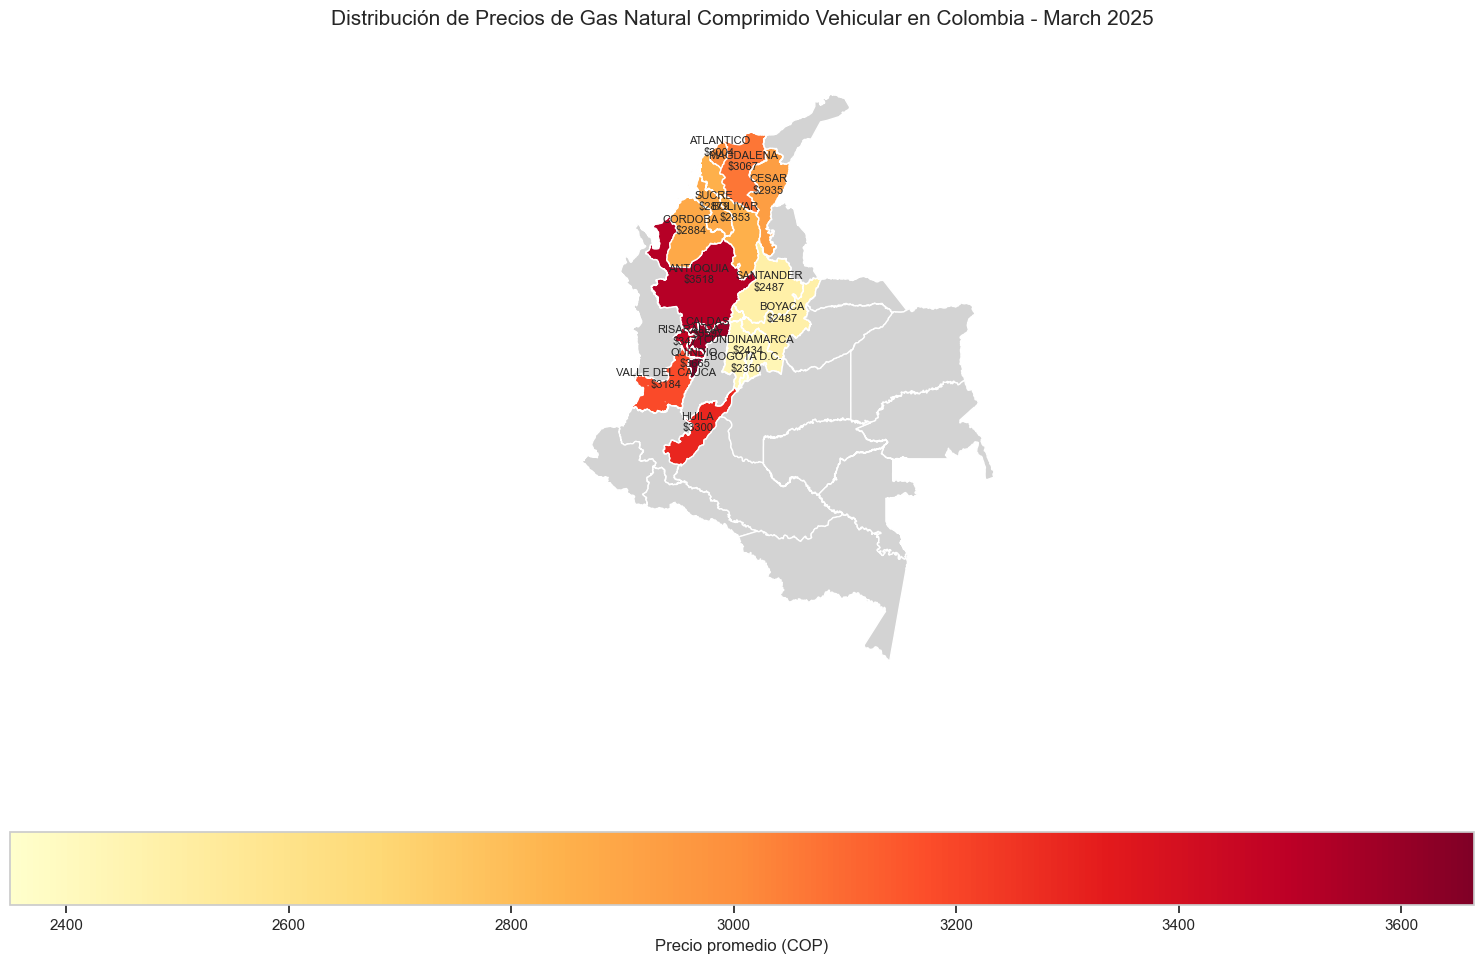

In [31]:
# Crear el mapa de precios actuales
fig, ax = crear_mapa_precios(gdf_merged, 
                            precio_col, 
                            "Distribución de Precios de Gas Natural Comprimido Vehicular en Colombia",
                            ultimo_mes)

plt.tight_layout()
plt.savefig('mapa_precios_gncv_colombia.png', dpi=300, bbox_inches='tight')
plt.show()



## Interpretación de los colores  
- **Colores claros (amarillo)**: Indican precios más bajos.  
- **Colores oscuros (rojo/burdeos)**: Representan precios más altos.  

##  Hallazgos clave  
 **Departamentos con precios más altos**  
   - Destacan zonas como **Antioquia, Valle del Cauca y algunos sectores del Caribe** con los precios más elevados (por encima de **$3,400 COP**).  
   - Esto podría deberse a factores como **costos de distribución, impuestos locales o demanda del GNC**.  

 **Departamentos con precios más bajos** 
   - En **Boyacá, Santander y partes de la región Andina**, se observan precios más bajos (cerca de **$2,400 - $2,600 COP**).  
   - Es posible que estas zonas tengan **mejor infraestructura de distribución de gas natural o incentivos para su uso**.  

# Precios de GNCV por Municipio – Marzo 2025

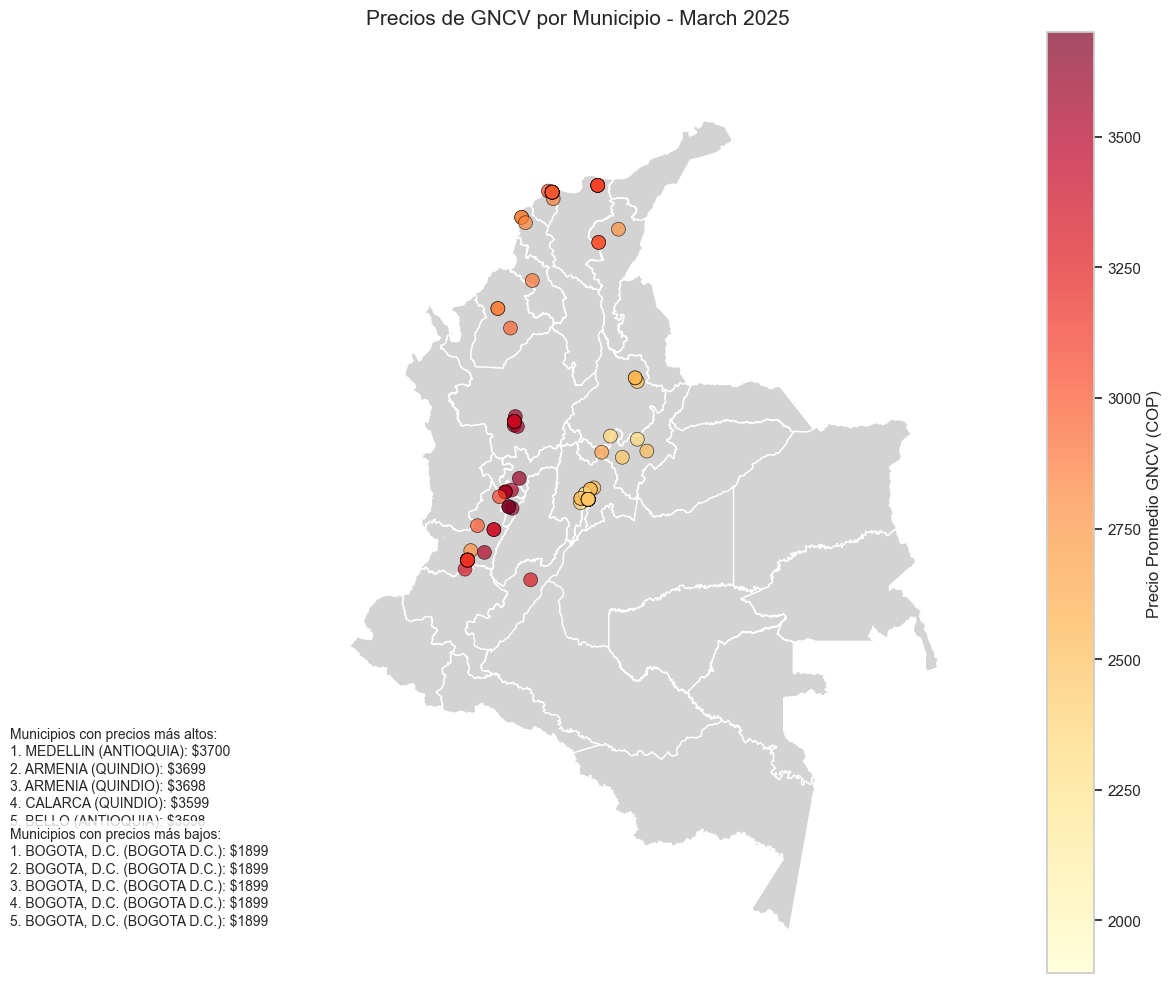

In [32]:
# Crear un segundo mapa que use las coordenadas exactas de los municipios
# Crear un GeoDataFrame a partir de las coordenadas de municipios en los datos
gdf_puntos = gpd.GeoDataFrame(
    df_ultimo_mes,
    geometry=gpd.points_from_xy(df_ultimo_mes['LONGITUD_MUNICIPIO'], df_ultimo_mes['LATITUD_MUNICIPIO']),
    crs="EPSG:4326"  # Definir sistema de coordenadas WGS84
)

# Crear mapa con puntos de precios
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Dibujar el mapa base de Colombia
gdf_colombia.plot(ax=ax, color='lightgrey', edgecolor='white')

# Crear una paleta de colores para los puntos
vmin = df_ultimo_mes[precio_col].min()
vmax = df_ultimo_mes[precio_col].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

# Dibujar los puntos con colores según precio
scatter = ax.scatter(
    gdf_puntos.geometry.x, 
    gdf_puntos.geometry.y, 
    c=gdf_puntos[precio_col],
    cmap=cmap,
    norm=norm,
    alpha=0.7,
    s=100,
    edgecolor='black',
    linewidth=0.5
)
# Añadir barra de colores
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Precio Promedio GNCV (COP)')

# Añadir título
ax.set_title(f"Precios de GNCV por Municipio - {ultimo_mes.strftime('%B %Y')}", fontsize=15)

# Añadir leyenda con los 5 municipios con precios más altos y más bajos
top_5_altos = df_ultimo_mes.nlargest(5, precio_col)
top_5_bajos = df_ultimo_mes.nsmallest(5, precio_col)

# Crear textos para la leyenda
text_altos = "Municipios con precios más altos:\n"
for i, (_, row) in enumerate(top_5_altos.iterrows(), 1):
    text_altos += f"{i}. {row['MUNICIPIO_EDS']} ({row['DEPARTAMENTO_EDS']}): ${row[precio_col]:.0f}\n"

text_bajos = "Municipios con precios más bajos:\n"
for i, (_, row) in enumerate(top_5_bajos.iterrows(), 1):
    text_bajos += f"{i}. {row['MUNICIPIO_EDS']} ({row['DEPARTAMENTO_EDS']}): ${row[precio_col]:.0f}\n"

# Añadir textos al mapa
plt.figtext(0.15, 0.15, text_altos, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.figtext(0.15, 0.05, text_bajos, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# Quitar ejes
ax.set_axis_off()

plt.tight_layout()
plt.savefig('mapa_precios_gncv_municipios.png', dpi=300, bbox_inches='tight')
plt.show()


 

## Interpretación de los colores  

- **Tonos amarillos**  → Municipios con precios más bajos.  
- **Tonos rojizos**  → Municipios con precios más altos.  

##  Hallazgos clave  
###  Municipios con precios más altos   
Los municipios con los costos más elevados de GNCV son:  
   1. **Medellín (Antioquia)** – $3,700 COP  
   2. **Armenia (Quindío)** – $3,699 COP  
   3. **Armenia (Quindío)** – $3,689 COP  
   4. **Calarcá (Quindío)** – $3,599 COP  
   5. **Bello (Antioquia)** – $3,599 COP  

Se observa que **el Quindío y Antioquia tienen los precios más altos**, lo que podría estar influenciado por factores como **costos de transporte, baja competencia o demanda alta en estas zonas**.  

### Municipios con precios más bajos  
Todos los valores mínimos corresponden a **Bogotá D.C.**, con un precio estable de **$1,899 COP**.  

 



# Variación de Precios del GNCV en Colombia (Enero 2021 - Marzo 2025)

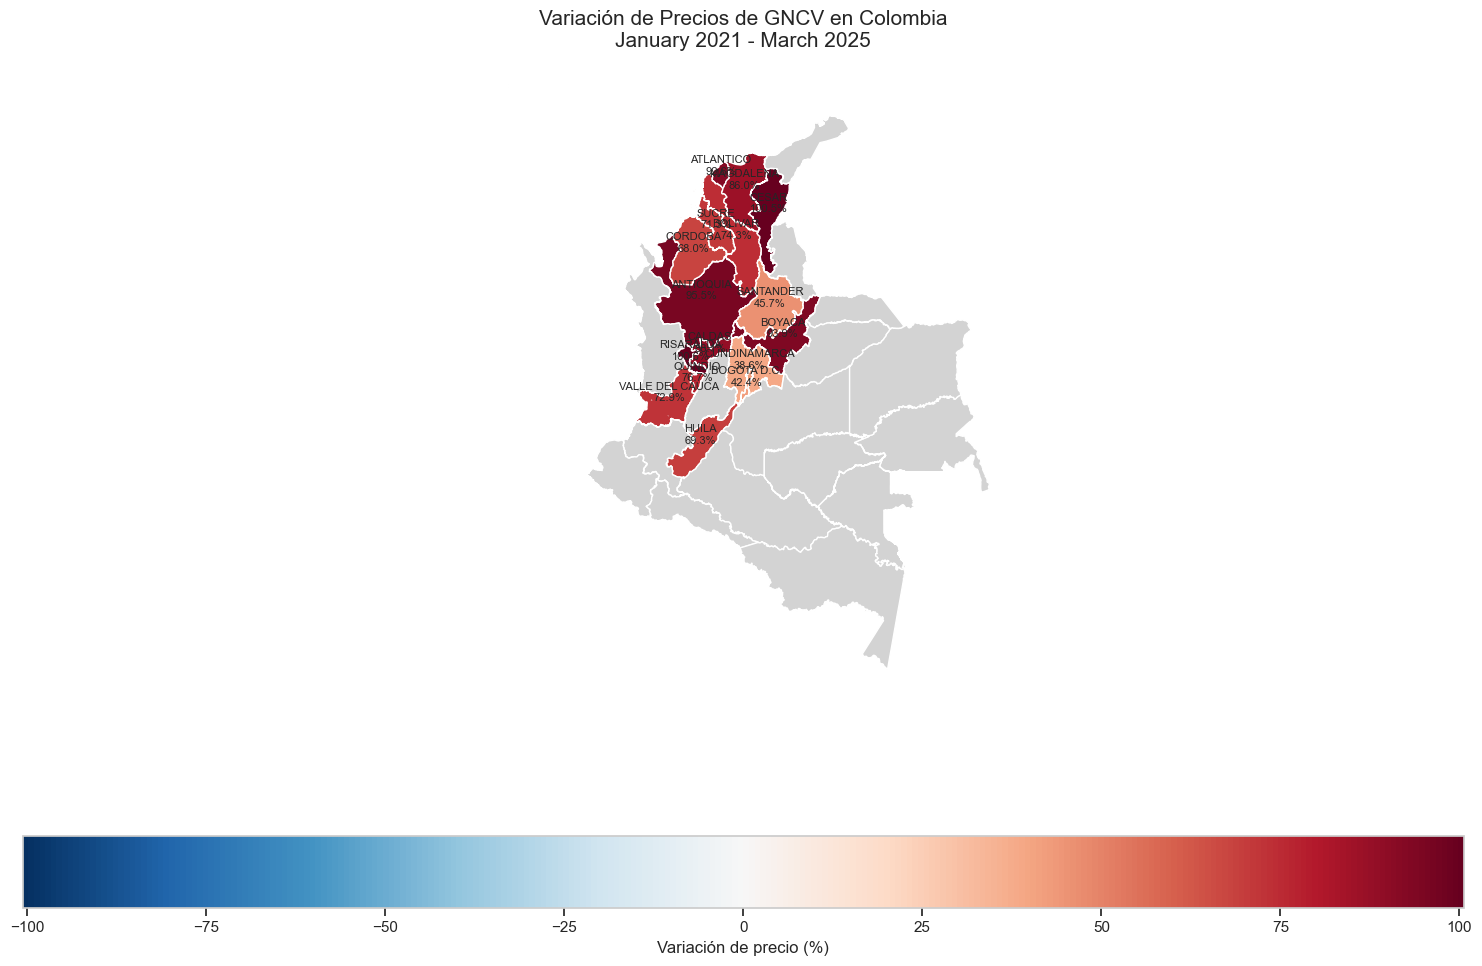

In [33]:
# Crear mapa de variación de precios entre el primer y último mes
primer_mes = df[fecha_col].min()
df_primer_mes = df[df[fecha_col] == primer_mes]

# Calcular precios promedios para el primer mes
precio_primer_mes = df_primer_mes.groupby(departamento_col)[precio_col].mean().reset_index()
precio_primer_mes.rename(columns={precio_col: 'precio_inicial'}, inplace=True)

# Calcular precios promedios para el último mes
precio_ultimo_mes = df_ultimo_mes.groupby(departamento_col)[precio_col].mean().reset_index()
precio_ultimo_mes.rename(columns={precio_col: 'precio_final'}, inplace=True)

# Unir ambos conjuntos de precios
precio_comparacion = precio_primer_mes.merge(precio_ultimo_mes, on=departamento_col)

# Calcular variación porcentual
precio_comparacion['variacion_porcentual'] = ((precio_comparacion['precio_final'] - precio_comparacion['precio_inicial']) / 
                                           precio_comparacion['precio_inicial']) * 100

# Unir con el shapefile
gdf_variacion = gdf_colombia.merge(precio_comparacion, left_on=departamento_geo_col, right_on=departamento_col, how='left')

# Crear mapa de variación de precios
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Usar una paleta divergente para mostrar aumentos y disminuciones
cmap_div = plt.cm.RdBu_r

# Encontrar el valor absoluto máximo para crear una escala simétrica
vmax = max(abs(gdf_variacion['variacion_porcentual'].min()), 
           abs(gdf_variacion['variacion_porcentual'].max()))

# Crear mapa con colores basados en la variación
gdf_variacion.plot(column='variacion_porcentual', 
                 ax=ax, 
                 legend=True,
                 cmap=cmap_div,
                 vmin=-vmax, vmax=vmax,
                 missing_kwds={'color': 'lightgrey'},
                 legend_kwds={'label': "Variación de precio (%)",
                              'orientation': "horizontal"})

periodo = f"{primer_mes.strftime('%B %Y')} - {ultimo_mes.strftime('%B %Y')}"
ax.set_title(f"Variación de Precios de GNCV en Colombia\n{periodo}", fontsize=15)

# Añadir nombres de departamentos y variación porcentual
for idx, row in gdf_variacion.iterrows():
    if pd.notna(row['variacion_porcentual']):
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(x, y, f"{row[departamento_geo_col]}\n{row['variacion_porcentual']:.1f}%", 
                horizontalalignment='center', fontsize=8)

# Quitar ejes
ax.set_axis_off()

plt.tight_layout()
plt.savefig('variacion_precios_gncv_colombia.png', dpi=300, bbox_inches='tight')
plt.show()



### Tendencia general
- **Aumento generalizado**: Todos los departamentos analizados muestran variaciones positivas (tonos rojos), indicando un incremento significativo en los precios del Gas Natural Comprimido Vehicular durante este período de cuatro años.

### Análisis por regiones

#### Región Caribe (Norte)
- **Incrementos más altos**: 
  - **Cesar y Magdalena**: >75% (máximos incrementos)
  - **Bolívar**: Aproximadamente 75%
  - **Atlántico**: Alrededor del 73%

#### Región Andina (Centro)
- **Incrementos moderados**:
  - **Santander**: 45.7%
  - **Cundinamarca**: ~42.8%
  - **Bogotá D.C.**: ~43%
  - **Risaralda**: Entre 40-45%

#### Región Occidental
- **Valle del Cauca**: Presenta uno de los aumentos más bajos entre los departamentos visualizados (~35%)

### Distribución espacial
- Los mayores incrementos se concentran en la región norte (costa Caribe)
- La región central muestra incrementos moderados
- Extensas áreas del país aparecen en gris, indicando ausencia de datos de estaciones GNCV

## Implicaciones económicas
Este incremento generalizado probablemente refleja:

1. Efectos inflacionarios durante el período 2021-2025
2. Modificaciones en políticas de fijación de precios de combustibles
3. Fluctuaciones en el mercado internacional del gas natural
4. Posibles cambios en la estructura impositiva aplicada a combustibles alternativos

## Conclusión
El mercado del GNCV en Colombia ha experimentado un encarecimiento sustancial en el período analizado, con variaciones que oscilan entre 35% y más del 75%, presentando una clara diferenciación regional donde la costa norte ha sufrido los incrementos más pronunciados.